# 05 - Complex substituent replacement

This notebook uses the real Gaussian 16 transition-state output `2-TS1-Sp.log` as the parent molecule. Every replacement retains a 3D conformer, and `MolsToGridDofImage` draws SVG directly from the conformer-bearing RDKit molecules.

The stable single-site operation requires a query describing one connected pendant fragment with exactly one external non-ring attachment bond; the notebook also demonstrates the experimental two-anchor whole-fragment path. The examples cover a unique query replacement, `bind_idx`, `replace_all=True`, explicit `start_idx` / `end_idx`, metal coordination bonds, `E` / `Z` stereo policies, and failure boundaries.

Input file: ../../../tests/test_files/g16log/2-TS1-Sp.log
Parent frame: 0
Parent atoms / bonds / formula: 101 107 C44H45F3NNiO4PS2
Parent conformers / is 3D: 1 True


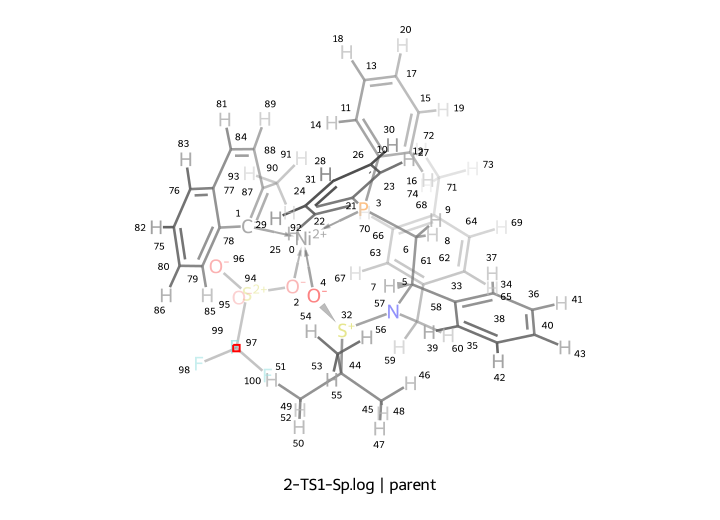

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [1]:
from pathlib import Path

import pandas as pd
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG, display
from rdkit import Chem
from rdkit_dof import MolsToGridDofImage
import py3Dmol

from molop import AutoParser, molopconfig
from molop.structure import replace_substituent
from molop.structure.substitution_sites import find_sites, normalize_query

# Show RDKit's 0-based atom indices in SVG so they can be matched to bind_idx/start_idx/end_idx.
IPythonConsole.drawOptions.addAtomIndices = True
molopconfig.quiet()
sample_candidates = (
    Path("tests/test_files/g16log/2-TS1-Sp.log"),
    Path("../../../tests/test_files/g16log/2-TS1-Sp.log"),
    Path("2-TS1-Sp.log"),
)
sample_path = next((path for path in sample_candidates if path.is_file()), None)
if sample_path is None:
    raise FileNotFoundError("Place 2-TS1-Sp.log beside the notebook, or run from the MolOP source tree.")

batch = AutoParser(sample_path, parser_detection="g16log", n_jobs=1, only_last_frame=True)
frame = batch[0][-1]
parent = frame.rdmol
if parent is None:
    raise ValueError("The Gaussian frame did not produce an editable RDKit molecule.")
parent = Chem.Mol(parent)

def show_svg(molecules, legends):
    if any(
        molecule.GetNumConformers() == 0 or not molecule.GetConformer().Is3D()
        for molecule in molecules
    ):
        raise ValueError("The SVG demo requires every molecule to retain a 3D conformer.")
    svg = MolsToGridDofImage(
        molecules,
        molsPerRow=min(2, len(molecules)),
        subImgSize=(720, 520),
        legends=legends,
        use_svg=True,
        return_image=False,
    )
    if not isinstance(svg, str):
        raise RuntimeError("rdkit-dof did not return SVG output.")
    display(SVG(data=svg))

def show_3d(molecules, legends):
    if len(molecules) != len(legends):
        raise ValueError("molecules and legends must have the same length.")
    viewer = py3Dmol.view(
        width=720 * len(molecules),
        height=520,
        viewergrid=(1, len(molecules)),
        linked=False,
    )
    for column, (molecule, _legend) in enumerate(zip(molecules, legends, strict=True)):
        viewer.addModel(
            Chem.MolToMolBlock(molecule, confId=0),
            "mol",
            viewer=(0, column),
        )
        viewer.setStyle({"stick": {"radius": 0.16}}, viewer=(0, column))
        conformer = molecule.GetConformer()
        for atom in molecule.GetAtoms():
            position = conformer.GetAtomPosition(atom.GetIdx())
            viewer.addLabel(
                str(atom.GetIdx()),
                {
                    "position": {"x": position.x, "y": position.y, "z": position.z},
                    "fontSize": 8,
                    "fontColor": "black",
                    "backgroundColor": "white",
                    "backgroundOpacity": 0.65,
                    "showBackground": True,
                    "inFront": True,
                },
                viewer=(0, column),
            )
        viewer.zoomTo(viewer=(0, column))
    viewer.show()

print("Input file:", sample_path)
print("Parent frame:", frame.frame_id)
print("Parent atoms / bonds / formula:", parent.GetNumAtoms(), parent.GetNumBonds(), frame.formula)
print("Parent conformers / is 3D:", parent.GetNumConformers(), parent.GetConformer().Is3D())
show_svg([parent], ["2-TS1-Sp.log | parent"])
show_3d([parent], ["2-TS1-Sp.log | parent"])

## 1. Discover real pendant substituent sites

The parent contains a sulfonyl CF₃ group, a tert-butyl group, and phenyl groups attached to phosphorus or the chelating carbon. The fused aromatic ligand has multiple external connections and is therefore rejected as a pendant fragment.

In [2]:
def site_rows(query):
    query_mol = normalize_query(query)
    rows = []
    for site in find_sites(parent, query_mol):
        scaffold = parent.GetAtomWithIdx(site.scaffold_atom)
        substituent = parent.GetAtomWithIdx(site.substituent_atom)
        rows.append({
            "query": query,
            "scaffold_idx": site.scaffold_atom,
            "scaffold_element": scaffold.GetSymbol(),
            "substituent_idx": site.substituent_atom,
            "substituent_element": substituent.GetSymbol(),
            "bond": str(site.bond_type),
            "matched_atoms": len(site.query_match),
        })
    return rows

site_table = pd.DataFrame(
    site_rows("C(F)(F)F") + site_rows("C(C)(C)C") + site_rows("c1ccccc1")
)
display(site_table)

,query,scaffold_idx,scaffold_element,substituent_idx,substituent_element,bond,matched_atoms
0,C(F)(F)F,94,S,97,C,SINGLE,4
1,C(C)(C)C,32,S,44,C,SINGLE,4
2,c1ccccc1,3,P,10,C,SINGLE,6
3,c1ccccc1,3,P,21,C,SINGLE,6
4,c1ccccc1,5,C,33,C,SINGLE,6


## 2. Unique query match: CF₃ → oxygenated substituent

The replacement uses an RDKit dummy-atom marker. In `[*]COC(=O)C`, `[*]` marks the new parent-to-substituent connection; the marker is removed during assembly while the real substituent atoms and conformer are retained.

Atoms / bonds / conformers after CF₃ replacement: 107 113 1


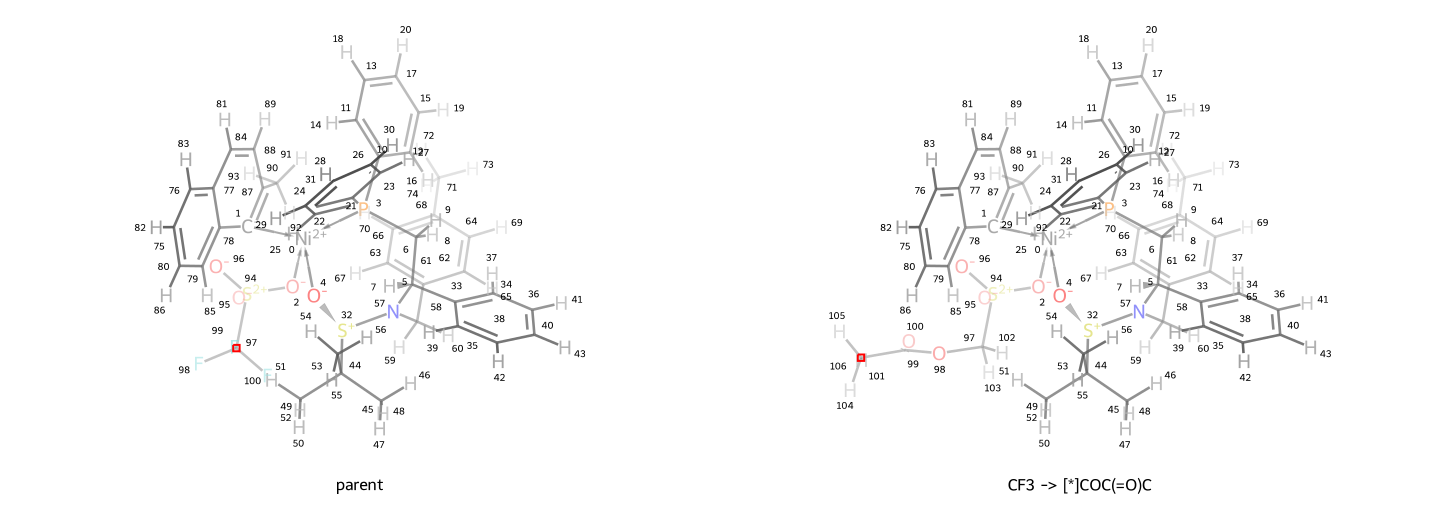

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [3]:
cf3_replaced = replace_substituent(
    parent, query="C(F)(F)F", replacement="[*]COC(=O)C",
    attempt_num=2, angle_split=8,
)
print("Atoms / bonds / conformers after CF₃ replacement:", cf3_replaced.GetNumAtoms(), cf3_replaced.GetNumBonds(), cf3_replaced.GetNumConformers())
show_svg([parent, cf3_replaced], ["parent", "CF3 -> [*]COC(=O)C"])
show_3d([parent, cf3_replaced], ["parent", "CF3 -> [*]COC(=O)C"])

## 3. Resolve multiple matches with `bind_idx`

The SMARTS `c1ccccc1` identifies several candidates. We select the phenyl group attached to the chelating carbon and replace only that site.

Phenyl candidates: 3 ; selected bind_idx: 5 ; conformers: 1


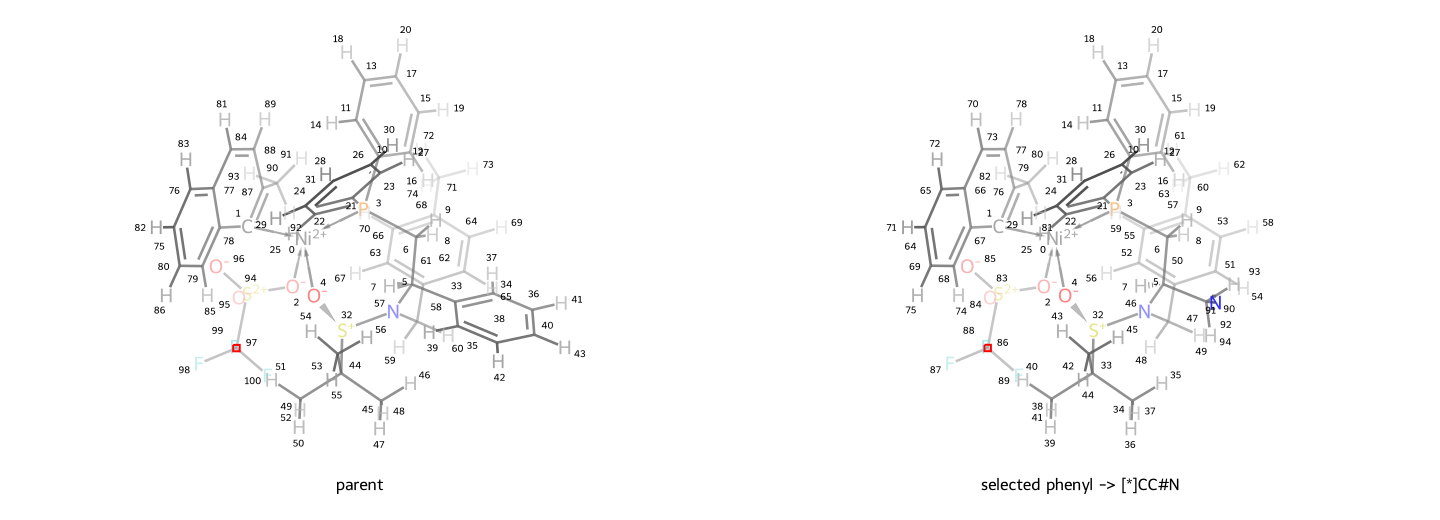

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [4]:
phenyl_query = normalize_query("c1ccccc1")
phenyl_sites = find_sites(parent, phenyl_query)
carbon_bound_phenyl = next(
    site for site in phenyl_sites
    if parent.GetAtomWithIdx(site.scaffold_atom).GetSymbol() == "C"
)
bind_idx = carbon_bound_phenyl.scaffold_atom
bound_replaced = replace_substituent(
    parent, query="c1ccccc1", replacement="[*]CC#N",
    bind_idx=bind_idx, attempt_num=2, angle_split=8,
)
print("Phenyl candidates:", len(phenyl_sites), "; selected bind_idx:", bind_idx, "; conformers:", bound_replaced.GetNumConformers())
show_svg([parent, bound_replaced], ["parent", "selected phenyl -> [*]CC#N"])
show_3d([parent, bound_replaced], ["parent", "selected phenyl -> [*]CC#N"])

## 4. Batch replacement with `replace_all=True`

Replace every pendant phenyl group with a cyanomethyl group. Generated atoms are marked internally so they cannot be matched again during the loop.

Remaining eligible phenyl sites after batch replacement: 0 ; conformers: 1


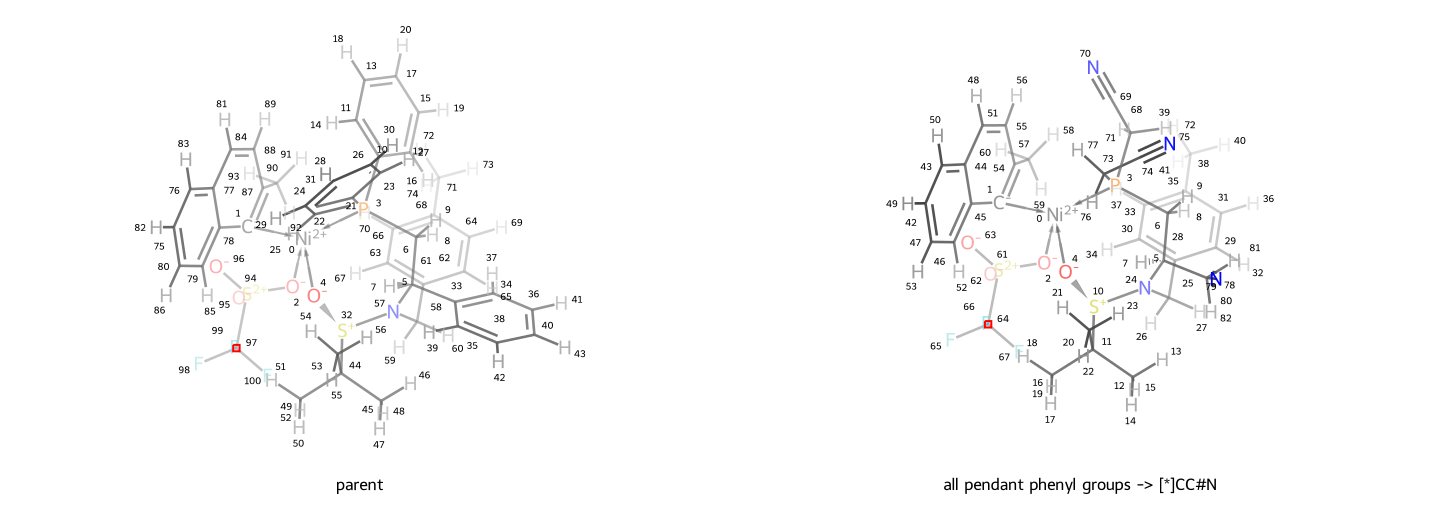

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
all_phenyl_replaced = replace_substituent(
    parent, query="c1ccccc1", replacement="[*]CC#N",
    replace_all=True, attempt_num=2, angle_split=8,
)
remaining_sites = find_sites(all_phenyl_replaced, phenyl_query)
print("Remaining eligible phenyl sites after batch replacement:", len(remaining_sites), "; conformers:", all_phenyl_replaced.GetNumConformers())
show_svg([parent, all_phenyl_replaced], ["parent", "all pendant phenyl groups -> [*]CC#N"])
show_3d([parent, all_phenyl_replaced], ["parent", "all pendant phenyl groups -> [*]CC#N"])

## 5. Explicit sites and metal coordination bonds

Pass `query=None` with the scaffold and substituent atom indices when a query is not the clearest expression of intent. Here a real Ni–C coordination bond is replaced with Ni–N.

Explicit Ni–C atom indices: 0 1 ; conformers: 1


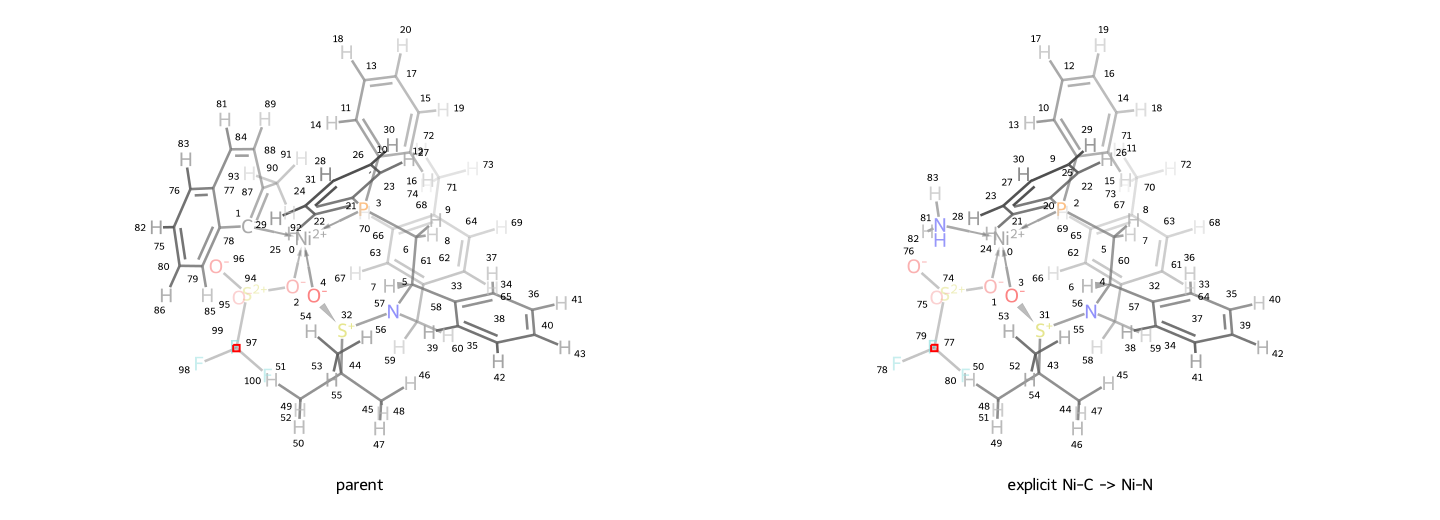

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [6]:
nickel = next(atom for atom in parent.GetAtoms() if atom.GetSymbol() == "Ni")
nickel_carbon = next(neighbor for neighbor in nickel.GetNeighbors() if neighbor.GetSymbol() == "C")
dative_replaced = replace_substituent(
    parent, query=None, replacement="[*]N",
    start_idx=nickel.GetIdx(), end_idx=nickel_carbon.GetIdx(),
    attempt_num=2, angle_split=8,
)
print("Explicit Ni–C atom indices:", nickel.GetIdx(), nickel_carbon.GetIdx(), "; conformers:", dative_replaced.GetNumConformers())
show_svg([parent, dative_replaced], ["parent", "explicit Ni-C -> Ni-N"])
show_3d([parent, dative_replaced], ["parent", "explicit Ni-C -> Ni-N"])

## 6. Double-bond stereo policies

The Gaussian parent has no suitable non-aromatic double bond for this isolated demonstration, so a minimal `FC=O` auxiliary molecule illustrates `stereo_policy="E"` and `stereo_policy="Z"`.

Generated both E and Z connecting-double-bond geometries.


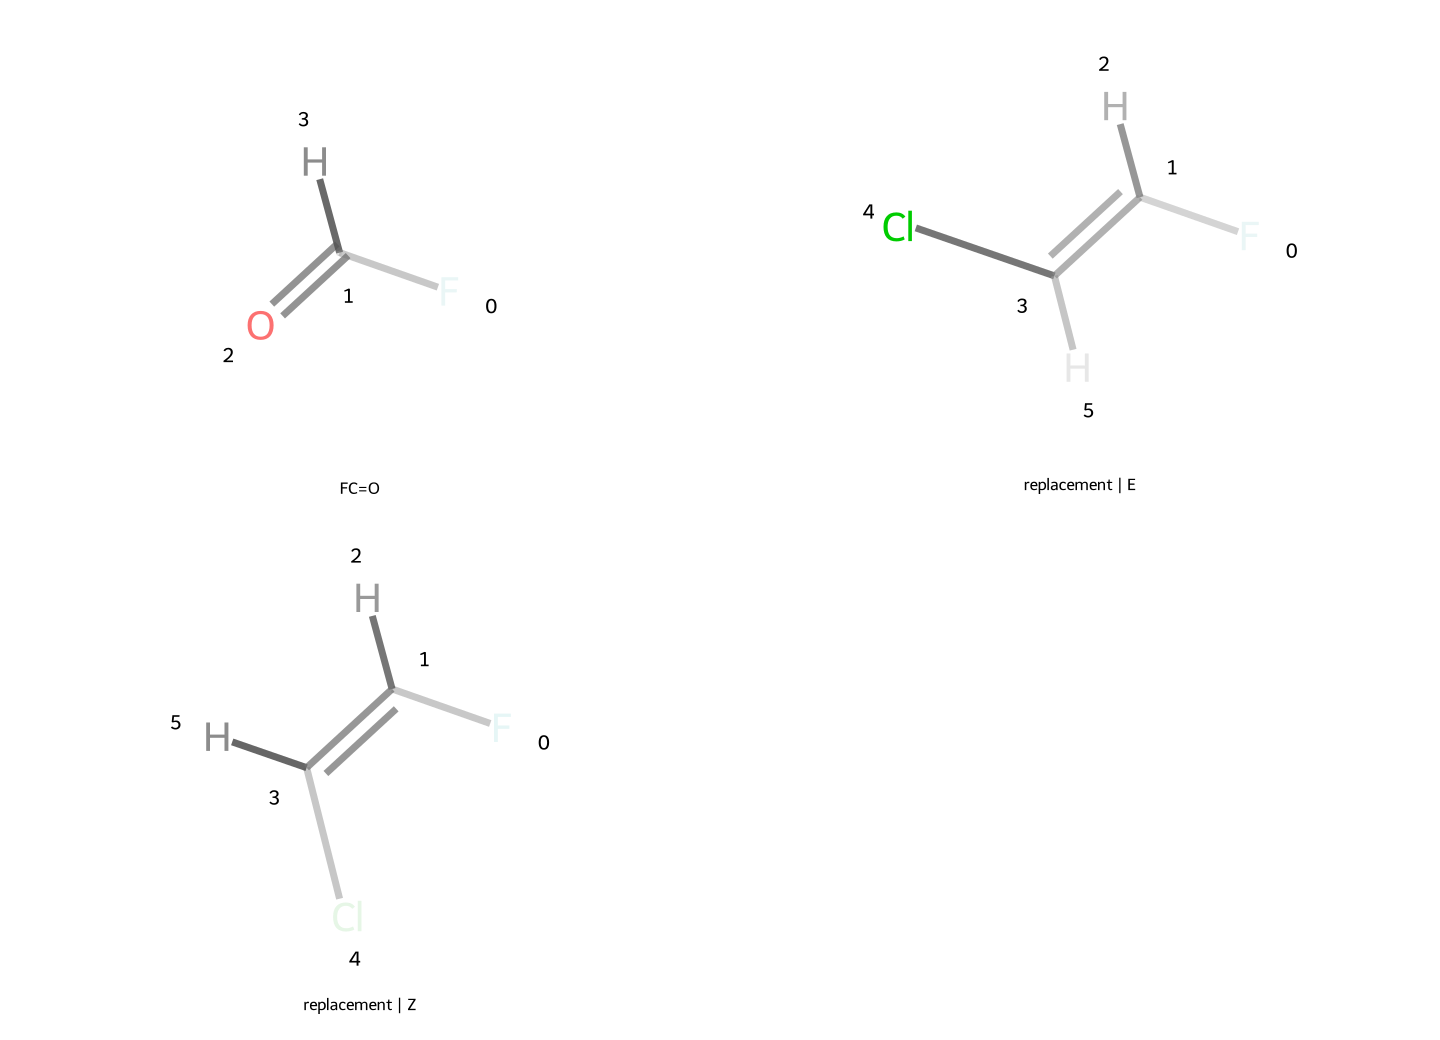

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
stereo_parent = Chem.MolFromSmiles("FC=O")
if stereo_parent is None:
    raise ValueError("Could not construct the stereo demonstration molecule.")
stereo_parent = Chem.AddHs(stereo_parent)
if AllChem.EmbedMolecule(stereo_parent, randomSeed=101) < 0:
    raise ValueError("Could not generate a 3D conformer for the stereo demonstration.")
stereo_e = replace_substituent(
    stereo_parent, query=None, replacement="[*]=[CH](Cl)",
    start_idx=1, end_idx=2, stereo_policy="E",
    attempt_num=2, randomSeed=101,
)
stereo_z = replace_substituent(
    stereo_parent, query=None, replacement="[*]=[CH](Cl)",
    start_idx=1, end_idx=2, stereo_policy="Z",
    attempt_num=2, randomSeed=101,
)
print("Generated both E and Z connecting-double-bond geometries.")
show_svg([stereo_parent, stereo_e, stereo_z], ["FC=O", "replacement | E", "replacement | Z"])
show_3d([stereo_parent, stereo_e, stereo_z], ["FC=O", "replacement | E", "replacement | Z"])

## 7. Experimental two-anchor whole-fragment replacement

The multi-anchor prototype can replace one connected fragment or several independent parent-side fragments. Here a conformer-bearing epoxide-like parent `C1CC2OC2C1` replaces `C1CO1` through two external single-bond anchors with a larger fused-ring fragment. The parent scaffold coordinates are frozen; only rigid fitting and axial rotation sampling are applied to the new fragment.

,scaffold_idx,old_fragment_idx,bond
0,1,2,SINGLE
1,5,4,SINGLE


Two-anchor replacement atoms / conformers: 26 1


/tmp/ipykernel_24184/2888118581.py:25: ExperimentalWarning: Experimental API 'replace_multisite_substituent' is not stable; its behavior and interface may change without notice.
  multisite_replaced = replace_multisite_substituent(


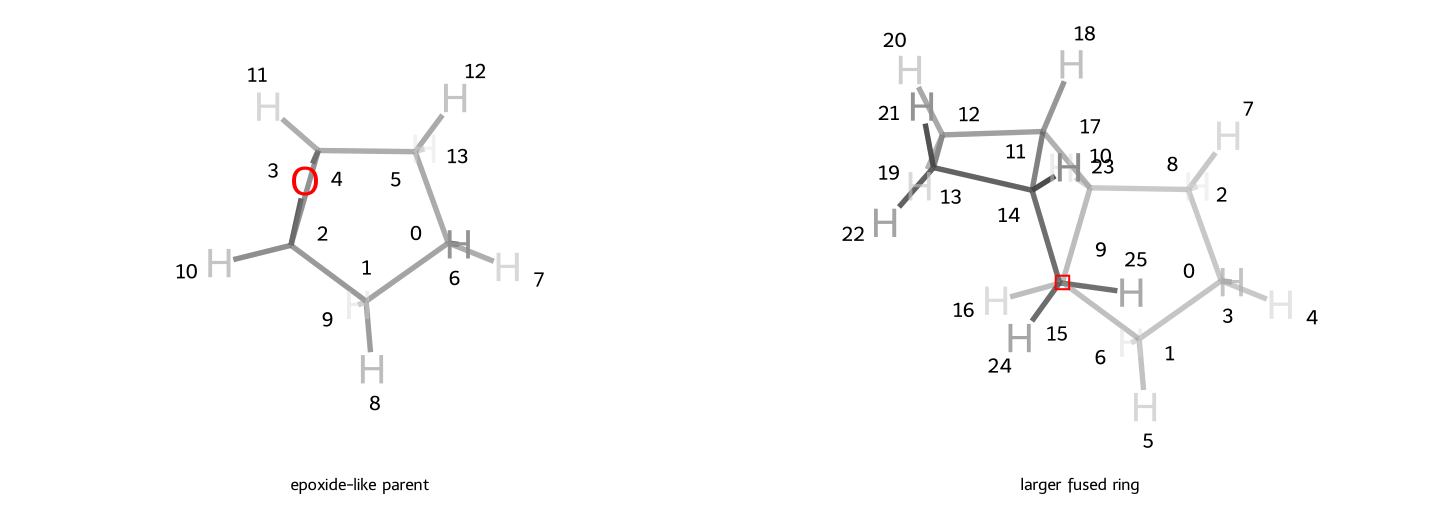

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
from molop.structure import replace_multisite_substituent
from molop.structure.substitution_sites import find_multisite_sites

multisite_parent = Chem.MolFromSmiles("C1CC2OC2C1")
if multisite_parent is None:
    raise ValueError("Could not construct the multi-anchor demo parent.")
multisite_parent = Chem.AddHs(multisite_parent)
if AllChem.EmbedMolecule(multisite_parent, randomSeed=7) < 0:
    raise ValueError("Could not generate a 3D conformer for the multi-anchor demo parent.")

multisite_sites = find_multisite_sites(
    multisite_parent, normalize_query("C1CO1"), anchor_count=2
)
anchor_table = pd.DataFrame(
    [
        {
            "scaffold_idx": anchor.scaffold_atom,
            "old_fragment_idx": anchor.substituent_atom,
            "bond": str(anchor.bond_type),
        }
        for anchor in multisite_sites[0].anchors
    ]
)
display(anchor_table)
multisite_replaced = replace_multisite_substituent(
    multisite_parent,
    query="C1CO1",
    replacement="[*]C1C([*])C2CCC2C1",
    attempt_num=2,
    angle_split=36,
)
print("Two-anchor replacement atoms / conformers:", multisite_replaced.GetNumAtoms(), multisite_replaced.GetNumConformers())
show_svg(
    [multisite_parent, multisite_replaced],
    ["epoxide-like parent", "larger fused ring"],
)
show_3d(
    [multisite_parent, multisite_replaced],
    ["epoxide-like parent", "larger fused ring"],
)

## 8. Three- and four-anchor modes

The three- and four-anchor cases now use one connected fragment attached to a connected scaffold chain: every atom of the target three- or four-membered ring participates in the boundary. The table lists all 3 and 4 boundary bonds row by row. The prototype fits all anchors as one rigid geometry instead of sampling rotation around one attachment axis, and both anchor sets must be non-collinear.

,case,anchor_rank,scaffold_idx,fragment_idx,bond
0,three anchors,0,0,3,SINGLE
1,three anchors,1,1,4,SINGLE
2,three anchors,2,2,5,SINGLE
3,four anchors,0,0,4,SINGLE
4,four anchors,1,1,5,SINGLE
5,four anchors,2,2,6,SINGLE
6,four anchors,3,3,7,SINGLE


Three-anchor / four-anchor atom counts: 21 30


/tmp/ipykernel_24184/4244957285.py:54: ExperimentalWarning: Experimental API 'replace_multisite_substituent' is not stable; its behavior and interface may change without notice.
  three_anchor_replaced = replace_multisite_substituent(
/tmp/ipykernel_24184/4244957285.py:61: ExperimentalWarning: Experimental API 'replace_multisite_substituent' is not stable; its behavior and interface may change without notice.
  four_anchor_replaced = replace_multisite_substituent(


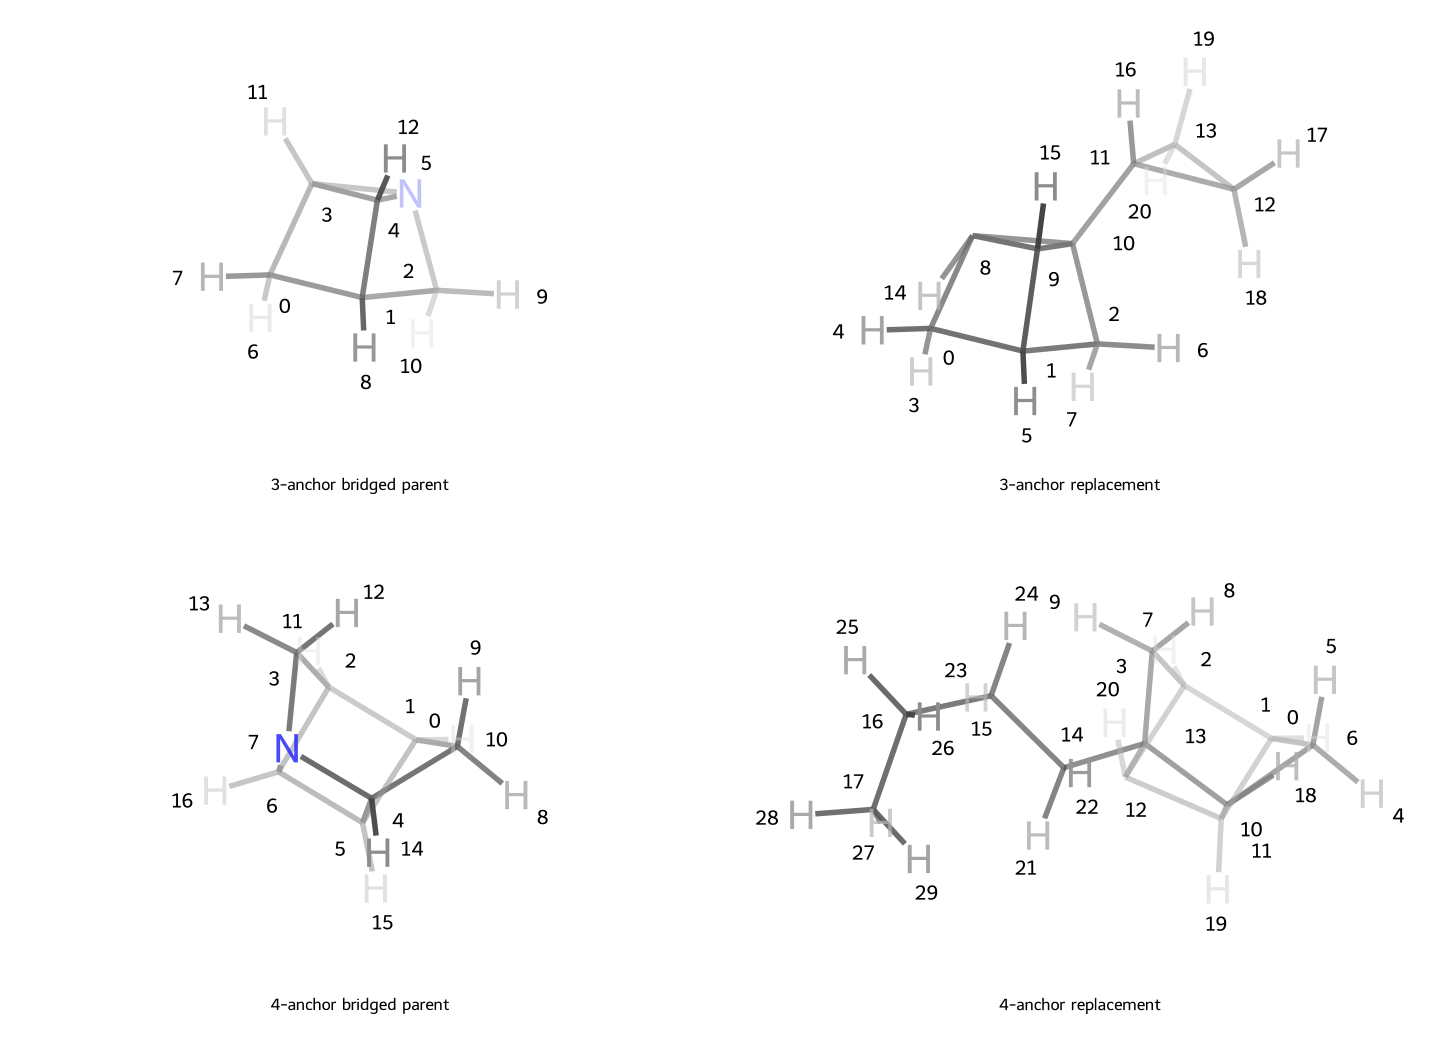

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [9]:
def build_bridge_parent(anchor_count, random_seed):
    """Build a connected scaffold chain bridged to one multi-anchor ring."""
    rw_mol = Chem.RWMol()
    scaffold = [rw_mol.AddAtom(Chem.Atom("C")) for _ in range(anchor_count)]
    fragment = [
        rw_mol.AddAtom(Chem.Atom("N" if index == anchor_count - 1 else "C"))
        for index in range(anchor_count)
    ]
    for index in range(anchor_count - 1):
        rw_mol.AddBond(scaffold[index], scaffold[index + 1], Chem.BondType.SINGLE)
    for index in range(anchor_count):
        rw_mol.AddBond(fragment[index], fragment[(index + 1) % anchor_count], Chem.BondType.SINGLE)
        rw_mol.AddBond(scaffold[index], fragment[index], Chem.BondType.SINGLE)
    parent = rw_mol.GetMol()
    Chem.SanitizeMol(parent)
    parent = Chem.AddHs(parent)
    if AllChem.EmbedMolecule(parent, randomSeed=random_seed) < 0:
        raise ValueError("Could not generate a 3D conformer for the multi-anchor demo parent.")
    return parent

three_anchor_parent = build_bridge_parent(anchor_count=3, random_seed=17)
four_anchor_parent = build_bridge_parent(anchor_count=4, random_seed=23)

three_anchor_sites = find_multisite_sites(
    three_anchor_parent, normalize_query("C1CN1"), anchor_count=3
)
four_anchor_sites = find_multisite_sites(
    four_anchor_parent, normalize_query("C1CCN1"), anchor_count=4
)
display(
    pd.DataFrame(
        [
            {
                "case": "three anchors",
                "anchor_rank": rank,
                "scaffold_idx": anchor.scaffold_atom,
                "fragment_idx": anchor.substituent_atom,
                "bond": str(anchor.bond_type),
            }
            for rank, anchor in enumerate(three_anchor_sites[0].anchors)
        ]
        + [
            {
                "case": "four anchors",
                "anchor_rank": rank,
                "scaffold_idx": anchor.scaffold_atom,
                "fragment_idx": anchor.substituent_atom,
                "bond": str(anchor.bond_type),
            }
            for rank, anchor in enumerate(four_anchor_sites[0].anchors)
        ]
    )
)
three_anchor_replaced = replace_multisite_substituent(
    three_anchor_parent,
    query="C1CN1",
    replacement="[*]C1C([*])C1([*])C2CC2",
    attempt_num=2,
    crowding_threshold=0.3,
)
four_anchor_replaced = replace_multisite_substituent(
    four_anchor_parent,
    query="C1CCN1",
    replacement="[*]C1C([*])C([*])C1([*])CCCC",
    attempt_num=2,
)
print("Three-anchor / four-anchor atom counts:", three_anchor_replaced.GetNumAtoms(), four_anchor_replaced.GetNumAtoms())
show_svg(
    [three_anchor_parent, three_anchor_replaced, four_anchor_parent, four_anchor_replaced],
    ["3-anchor bridged parent", "3-anchor replacement", "4-anchor bridged parent", "4-anchor replacement"],
)
show_3d(
    [three_anchor_parent, three_anchor_replaced, four_anchor_parent, four_anchor_replaced],
    ["3-anchor bridged parent", "3-anchor replacement", "4-anchor bridged parent", "4-anchor replacement"],
)

## 9. Disconnected parent fragments

A multi-anchor query does not need to be connected. Here the two oxygen atoms in OCCO are selected by O.O; the two independent pendant groups are replaced together by a doubly marked chain. The parent scaffold coordinates remain fixed.

,scaffold_idx,old_fragment_idx,bond
0,1,0,SINGLE
1,2,3,SINGLE


Disconnected-query replacement atoms / conformers: 18 1


/tmp/ipykernel_24184/232434793.py:26: ExperimentalWarning: Experimental API 'replace_multisite_substituent' is not stable; its behavior and interface may change without notice.
  disconnected_replaced = replace_multisite_substituent(


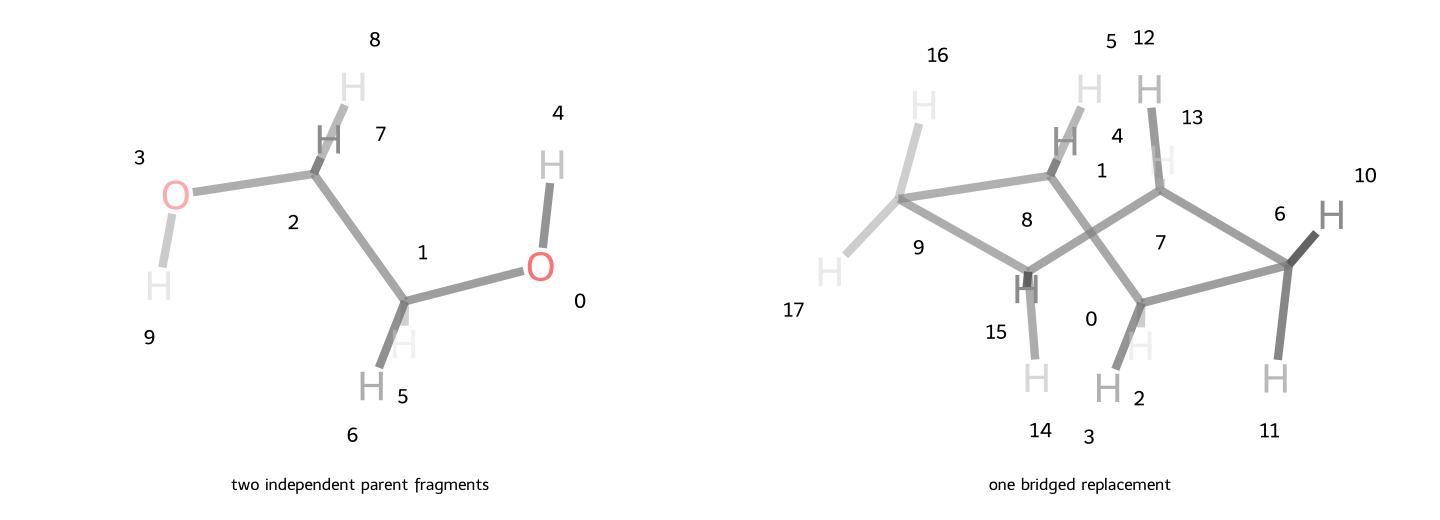

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [10]:
disconnected_parent = Chem.MolFromSmiles("OCCO")
if disconnected_parent is None:
    raise ValueError("Could not construct the disconnected-query demo parent.")
disconnected_parent = Chem.AddHs(disconnected_parent)
if AllChem.EmbedMolecule(disconnected_parent, randomSeed=31) < 0:
    raise ValueError("Could not generate a 3D conformer for the disconnected-query demo.")

disconnected_sites = find_multisite_sites(
    disconnected_parent,
    normalize_query("O.O", require_connected=False),
    anchor_count=2,
)
if len(disconnected_sites) != 1:
    raise ValueError("The disconnected query did not resolve to one two-anchor site.")
disconnected_anchor_table = pd.DataFrame(
    [
        {
            "scaffold_idx": anchor.scaffold_atom,
            "old_fragment_idx": anchor.substituent_atom,
            "bond": str(anchor.bond_type),
        }
        for anchor in disconnected_sites[0].anchors
    ]
)
display(disconnected_anchor_table)
disconnected_replaced = replace_multisite_substituent(
    disconnected_parent,
    query="O.O",
    replacement="[*]CCCC[*]",
    attempt_num=2,
    crowding_threshold=0.1,
    anchor_tolerance=0.5,
    randomSeed=31,
)
print("Disconnected-query replacement atoms / conformers:", disconnected_replaced.GetNumAtoms(), disconnected_replaced.GetNumConformers())
show_svg(
    [disconnected_parent, disconnected_replaced],
    ["two independent parent fragments", "one bridged replacement"],
)
show_3d(
    [disconnected_parent, disconnected_replaced],
    ["two independent parent fragments", "one bridged replacement"],
)

## 10. Failure boundaries

Arbitrary subgraph replacement is not the goal of this API. An ambiguous query must use `bind_idx` or `replace_all`, and a ring bond is explicitly rejected.

In [11]:
errors = {}
try:
    replace_substituent(parent, query="C", replacement="[*]C", attempt_num=1)
except ValueError as error:
    errors["ambiguous query"] = str(error)
ring_bond = next(bond for bond in parent.GetBonds() if bond.IsInRing())
try:
    replace_substituent(
        parent, query=None, replacement="[*]C",
        start_idx=ring_bond.GetBeginAtomIdx(), end_idx=ring_bond.GetEndAtomIdx(),
        attempt_num=1,
    )
except ValueError as error:
    errors["ring bond"] = str(error)
display(pd.DataFrame(list(errors.items()), columns=["case", "error"]))

,case,error
0,ambiguous query,query identifies multiple pendant substituents...
1,ring bond,substituent replacement does not support ring ...
